In [75]:
# ============================================================
# STAGE 2: DATA COLLECTION & DATA UNDERSTANDING
# ============================================================

In [6]:
# The ParserError (EOF inside string) is occurring in cell V1JGYb2BdgPE
# when reading the CSV, not related to package installations in this cell.
# Please see the explanation for the fix to be applied in cell V1JGYb2BdgPE.
!pip install nltk wordcloud -q

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from collections import Counter

sns.set_style("whitegrid")

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [40]:
df = pd.read_csv(
    "email_dataset_classification.csv",
    engine='python',
    on_bad_lines='skip'
)

In [41]:
df.head()

,Unnamed: 0,message,label
0,0,['Fabulous discounts from CanadianPharmacy. 50...,1
1,1,http://houston.cowparade.net/,0
2,2,=================================\n\nGuarantee...,1
3,3,Thanks for your help! ---------------------- ...,0
4,4,Start Date: 10/13/01; HourAhead hour: 23; No a...,0


In [42]:
print(df.columns)

Index(['Unnamed: 0', 'message', 'label'], dtype='object')


In [43]:
print(df['label'].value_counts())

label
0                                                   140689
1                                                    60358
                                                       472
 int depth);                                           199
 const                                                  35
                                                     ...  
 BOOL *ppath_contains_wcard);                            1
 const struct eventlog_DeregisterClusterSvc *r);         1
 struct eventlog_RegisterEventSourceA *r);               1
 const struct eventlog_RegisterEventSourceA *r);         1
 struct eventlog_RegisterEventSourceW *r);               1
Name: count, Length: 275, dtype: int64


In [44]:
df = df[df['label'].isin(['0', '1', 0, 1])]

In [45]:
df['label'] = df['label'].astype(int)

In [46]:
print(df['label'].value_counts())

print(df['label'].unique())

label
0    140689
1     60358
Name: count, dtype: int64
[1 0]


In [47]:
print(df.shape)

(201047, 3)


In [48]:
df.isnull().sum()

,0
Unnamed: 0,0
message,0
label,0


In [49]:
df.dropna(inplace=True)

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.drop_duplicates(inplace=True)

print(df.shape)

(201047, 3)


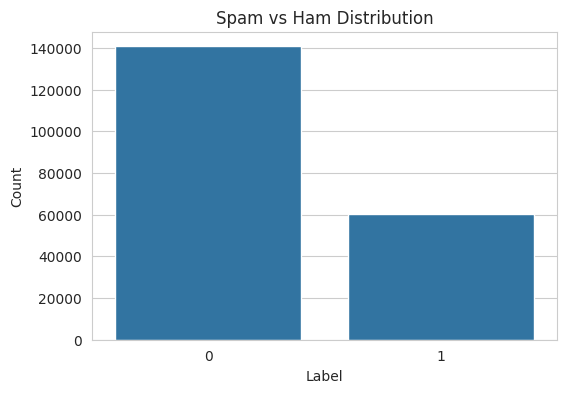

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['label'])

plt.title("Spam vs Ham Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [53]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [57]:
import re
import string

stop_words = set(stopwords.words('english'))

def preprocess_text_fast(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # split words
    words = text.split()

    # remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [58]:
df['cleaned_message'] = df['message'].astype(str).apply(preprocess_text_fast)

In [59]:
df.head()

,Unnamed: 0,message,label,cleaned_message
0,0,['Fabulous discounts from CanadianPharmacy. 50...,1,fabulous discounts canadianpharmacy discounts ...
1,1,http://houston.cowparade.net/,0,
2,2,=================================\n\nGuarantee...,1,guaranteed increase lift firm breasts days mon...
3,3,Thanks for your help! ---------------------- ...,0,thanks help tana joneshouect pm connie sutton ...
4,4,Start Date: 10/13/01; HourAhead hour: 23; No a...,0,start date hourahead hour ancillary schedules ...


In [60]:
df['char_count'] = df['message'].astype(str).apply(len)

In [61]:
df['word_count'] = df['message'].astype(str).apply(
    lambda x: len(x.split())
)

In [62]:
df['sentence_count'] = df['message'].astype(str).apply(
    lambda x: len(x.split('.'))
)

In [63]:
df.head()

,Unnamed: 0,message,label,cleaned_message,char_count,word_count,sentence_count
0,0,['Fabulous discounts from CanadianPharmacy. 50...,1,fabulous discounts canadianpharmacy discounts ...,554,77,9
1,1,http://houston.cowparade.net/,0,,29,1,3
2,2,=================================\n\nGuarantee...,1,guaranteed increase lift firm breasts days mon...,773,103,13
3,3,Thanks for your help! ---------------------- ...,0,thanks help tana joneshouect pm connie sutton ...,827,144,6
4,4,Start Date: 10/13/01; HourAhead hour: 23; No a...,0,start date hourahead hour ancillary schedules ...,707,81,9


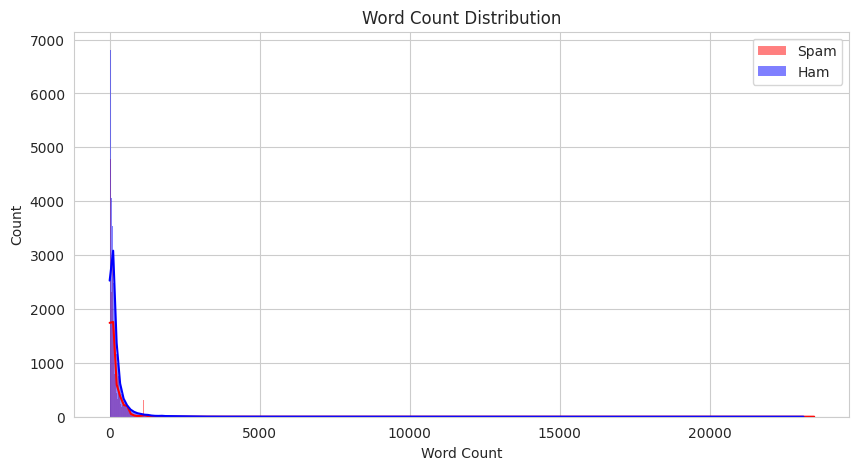

In [64]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['label']==1]['word_count'],
    color='red',
    label='Spam',
    kde=True
)

sns.histplot(
    df[df['label']==0]['word_count'],
    color='blue',
    label='Ham',
    kde=True
)

plt.legend()

plt.title("Word Count Distribution")

plt.xlabel("Word Count")

plt.show()

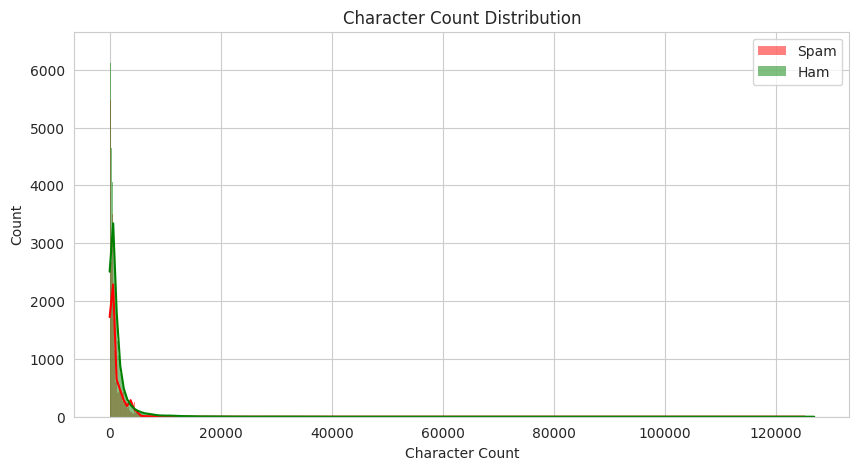

In [65]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['label']==1]['char_count'],
    color='red',
    label='Spam',
    kde=True
)

sns.histplot(
    df[df['label']==0]['char_count'],
    color='green',
    label='Ham',
    kde=True
)

plt.legend()

plt.title("Character Count Distribution")

plt.xlabel("Character Count")

plt.show()

In [66]:
spam_words = " ".join(
    df[df['label']==1]['cleaned_message']
)

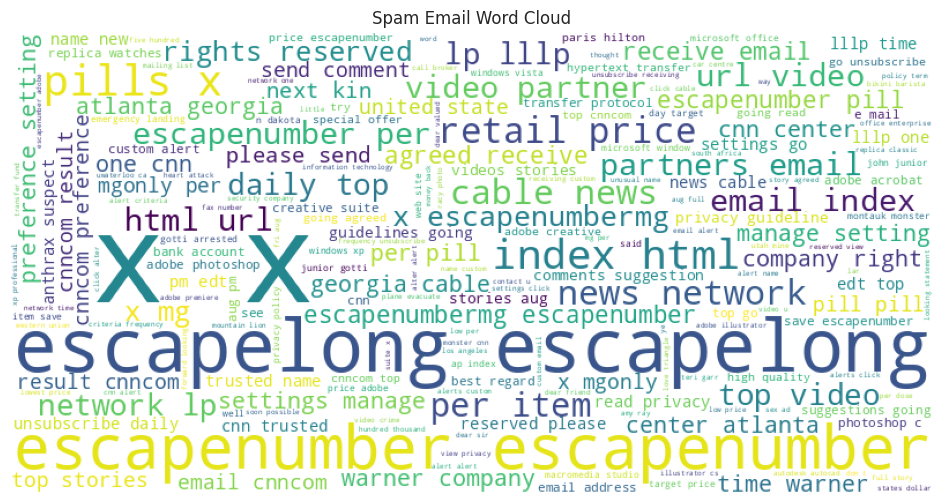

In [67]:
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(12,6))

plt.imshow(spam_wordcloud)

plt.axis('off')

plt.title("Spam Email Word Cloud")

plt.show()

In [68]:
ham_words = " ".join(
    df[df['label']==0]['cleaned_message']
)

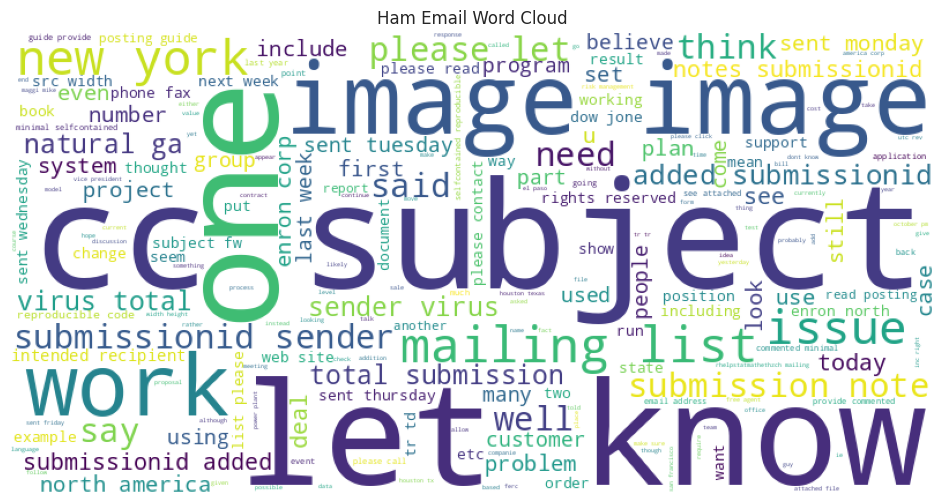

In [69]:
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.figure(figsize=(12,6))

plt.imshow(ham_wordcloud)

plt.axis('off')

plt.title("Ham Email Word Cloud")

plt.show()

In [70]:
spam_corpus = []

for msg in df[df['label']==1]['cleaned_message']:

    for word in msg.split():

        spam_corpus.append(word)

spam_common_words = Counter(
    spam_corpus
).most_common(20)

spam_common_df = pd.DataFrame(
    spam_common_words,
    columns=['Word', 'Count']
)

spam_common_df

,Word,Count
0,x,157983
1,escapenumber,71543
2,escapelong,39371
3,com,32133
4,cnn,27370
5,email,25813
6,one,22819
7,us,22364
8,money,19534
9,price,19197


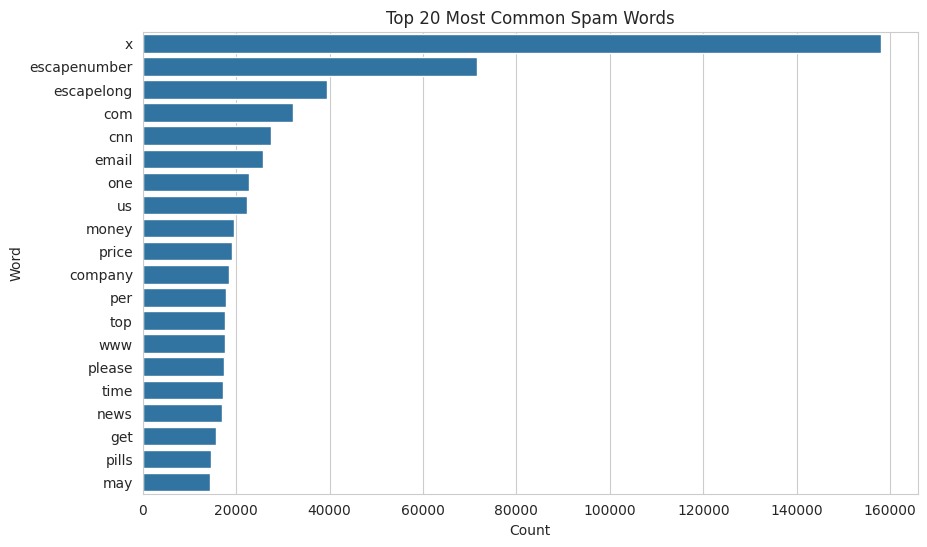

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=spam_common_df,
    x='Count',
    y='Word'
)

plt.title("Top 20 Most Common Spam Words")

plt.show()

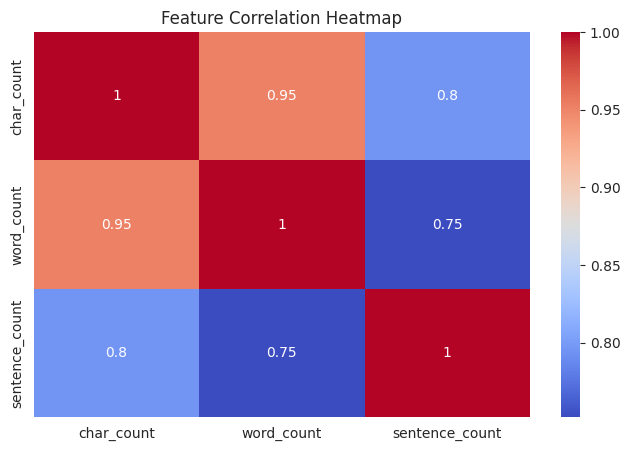

In [72]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['char_count', 'word_count', 'sentence_count']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [73]:
df.describe()

,label,char_count,word_count,sentence_count
count,201047.000000,201047.00000,201047.000000,201047.000000
mean,0.300218,1490.93497,225.075554,20.532477
std,0.458354,3524.13387,515.994316,49.391882
min,0.000000,1.00000,0.000000,1.000000
25%,0.000000,280.00000,44.000000,4.000000
50%,0.000000,665.00000,105.000000,9.000000
75%,1.000000,1527.00000,236.000000,18.000000
max,1.000000,126847.00000,23480.000000,2873.000000


In [74]:
df.to_csv(
    "cleaned_email_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
